# 9 Image Processing

**Computational Thinking for Life Scientists**

Colab slideshow notebook

Main theme: basic image-processing tools for biological images, especially **cell quantification**.

## 9 Image Processing - What is image processing?

Image processing refers to manipulating or analyzing digital images.

- **Manipulation** changes pixels to make an image more meaningful or informative.
- **Analysis** extracts information without necessarily changing pixels.

This chapter covers:

1. Segmentation
2. Morphological operators: erosion and dilation
3. Noise reduction
4. Labeling and cell counting

## 9 Image Processing - Biological motivation

A central biological example in this chapter is **cell quantification**: counting cells in microscopy images.

Why this is nontrivial:

- Different image types and resolutions
- Different labeling techniques
- Varying image quality
- Cells may be close together or partially merged

There is usually no universal best algorithm; solutions are often tailored to a specific image type.

## 9.1 Segmentation

Image segmentation partitions an image into segments: sets of pixels that share similar color, intensity, or other properties.

Main purpose:

- Simplify the image representation
- Prepare for object recognition
- Locate boundaries and objects
- Support later analysis, such as counting, measuring, or tracking objects

## 9.1.1 Binary Segmentation by Thresholding

Binary segmentation turns a gray-level image into a black-and-white image.

For a threshold `thrd`:

- pixels with value `>= thrd` become white: `255`
- pixels with value `< thrd` become black: `0`

This is useful when the foreground and background have clearly different brightness.

## Figure 9.1

<img src="fig9.1.png" width="600">

**Figure 9.1.** (a) Drosophila Kc167 cells. (b) Binary segmentation, threshold = 27.

In [ ]:
from PIL import Image

def segment(im, thrd):
    '''Binary segmentation of image im by threshold thrd'''
    width, height = im.size
    out = Image.new(mode='L', size=(width, height))
    mat = im.load()
    out_mat = out.load()

    for x in range(width):
        for y in range(height):
            if mat[x, y] >= thrd:
                out_mat[x, y] = 255  # white
            else:
                out_mat[x, y] = 0    # black

    return out

In [9]:
from PIL import Image
from urllib.request import urlretrieve
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Load the image and convert it to grayscale
url = "https://raw.githubusercontent.com/ariefouren/BIU-bio-python-2026/main/03_Chapters/08_Digital_Images_Representation/slides/cell_color.png"

urlretrieve(url, "cell_color.png")
im = Image.open("cell_color.png").convert('L')
mat = im.load()

def show_threshold(th):
    out = Image.new('L', im.size)
    out_mat = out.load()

    width, height = im.size

    for x in range(width):
        for y in range(height):
            if mat[x,y] >= th:
                out_mat[x,y] = 255   # white
            else:
                out_mat[x,y] = 0     # black

    plt.figure(figsize=(6,6))
    plt.imshow(out, cmap='gray')
    plt.axis('off')
    plt.show()

widgets.interact(show_threshold, 
                 th=widgets.IntSlider(min=0,max=255,value=128))

interactive(children=(IntSlider(value=128, description='th', max=255), Output()), _dom_classes=('widget-intera…

<function __main__.show_threshold(th)>

## Code explained - `segment`

The function `segment(im, thrd)`:

- gets the image dimensions: `width, height = im.size`
- creates a new gray-level output image of the same size
- accesses the input and output pixel matrices
- scans all pixels and applies the threshold rule

The output is a binary image whose pixels are only `0` or `255`.

## Exercise 1

Modify `segment(im, thrd)` to perform ternary segmentation.

The new function `segment3(im, thrd1, thrd2)` should use:

- if `p < thrd1`, set pixel to black: `0`
- if `thrd1 <= p < thrd2`, set pixel to gray: `128`
- otherwise, set pixel to white: `255`

## Figure 9.2

<img src="fig9.2.png" width="600">

**Figure 9.2.** Binary segmentation with different thresholds: (a) 12, (b) 27, (c) 42.

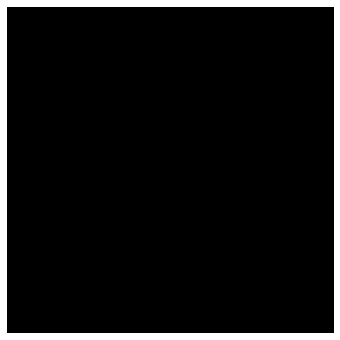

Threshold: 0


None

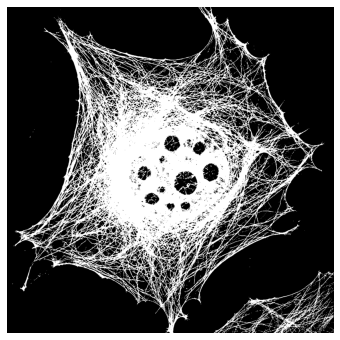

Threshold: 20


None

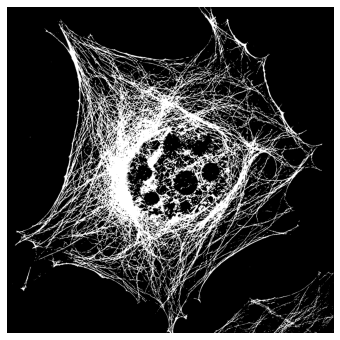

Threshold: 40


None

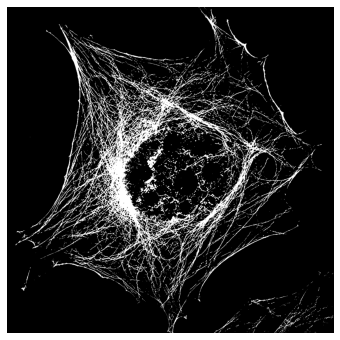

Threshold: 60


None

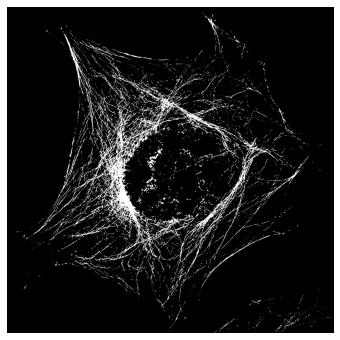

Threshold: 80


None

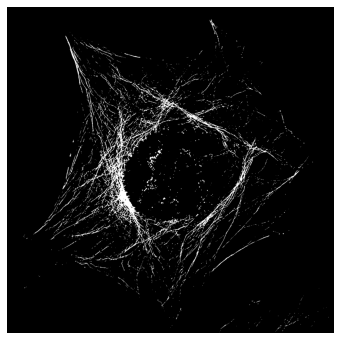

Threshold: 100


None

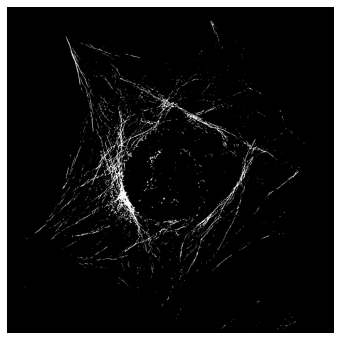

Threshold: 120


None

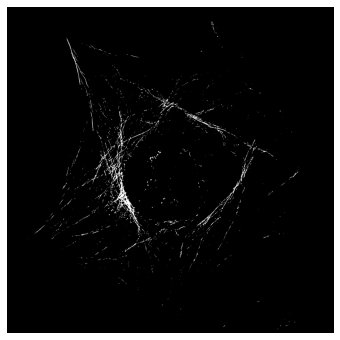

Threshold: 140


None

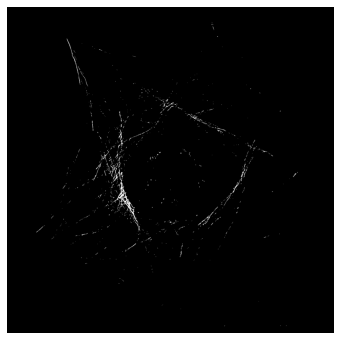

Threshold: 160


None

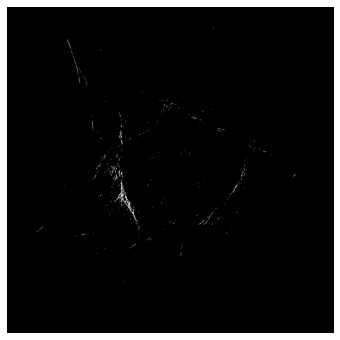

Threshold: 180


None

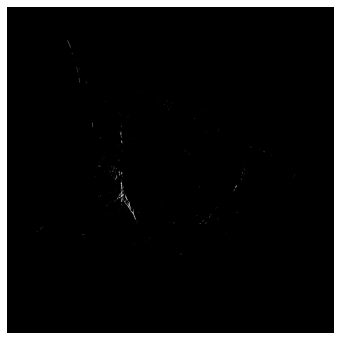

Threshold: 200


None

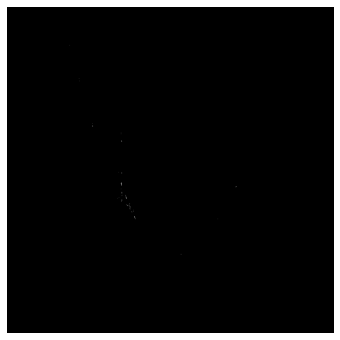

Threshold: 220


None

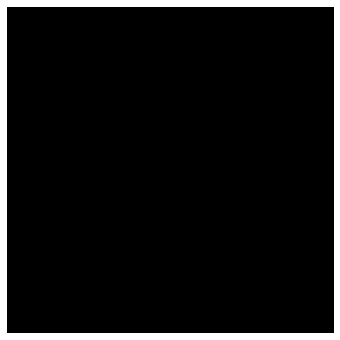

Threshold: 240


None

In [12]:
im = Image.open("cell_color.png").convert('L')

for th in range(0, 256, 20):  # Binary segmentation with various thresholds
    out_im = show_threshold(th)
    print(f"Threshold: {th}")
    display(out_im)

## 9.1.2 Otsu's Method

A good threshold should:

- minimize differences within each segment
- maximize differences between segments

**Otsu's method** assumes two pixel classes: foreground and background.

It searches for a threshold that best separates these two classes using the gray-level histogram.

## Figure 9.4

<img src="fig9.4.png" width="600">

**Figure 9.4.** Histogram for a photomicrographic view of Bacillus anthracis bacteria. Foreground and background are easily separable.

## Figure 9.5

<img src="fig9.5.png" width="600">

**Figure 9.5.** Histogram for a red blood cell image with Plasmodium vivax. Foreground and background are still separable.

## Figure 9.6

<img src="fig9.6.png" width="600">

**Figure 9.6.** Transmission electron microscopy of Protozoa, with no visually separable peaks in the histogram.

## 9.1.2 Otsu's Method - Histogram intuition

When foreground and background differ in brightness, the image histogram may be **bi-modal**.

- one peak corresponds to background pixels
- one peak corresponds to foreground pixels
- a good threshold is often near the low point between the peaks

When peaks overlap strongly, or when no two peaks are visible, Otsu's method may fail.

[301898, 326021, 160083, 68950, 41829, 27306, 22580, 19431, 17249, 16373, 14483, 13711, 12906, 11563, 11731, 10871, 10739, 9810, 9754, 9863, 9443, 9626, 9647, 9606, 9583, 9590, 9399, 9347, 9153, 8956, 8757, 8673, 8393, 8352, 8116, 7769, 7667, 7497, 7114, 6980, 6773, 6625, 6410, 6324, 6222, 6016, 5770, 5520, 5566, 5206, 5145, 5089, 5026, 4806, 4725, 4608, 4590, 4374, 4418, 4306, 4025, 4020, 4041, 3945, 3787, 3729, 3686, 3543, 3512, 3459, 3476, 3350, 3353, 3340, 3390, 3330, 3338, 3214, 3177, 3212, 3006, 2832, 2760, 2581, 2531, 2383, 2335, 2243, 2163, 2167, 2110, 2082, 1901, 1922, 1895, 1788, 1868, 1748, 1706, 1632, 1596, 1634, 1621, 1588, 1449, 1542, 1368, 1397, 1371, 1314, 1304, 1227, 1173, 1187, 1157, 1057, 1075, 1095, 1045, 1057, 955, 933, 996, 894, 885, 829, 844, 876, 834, 812, 767, 725, 730, 713, 710, 628, 679, 672, 603, 628, 596, 575, 562, 566, 509, 512, 506, 471, 468, 451, 436, 408, 415, 434, 414, 363, 376, 346, 393, 334, 332, 314, 296, 312, 313, 290, 275, 250, 242, 259, 231, 235,

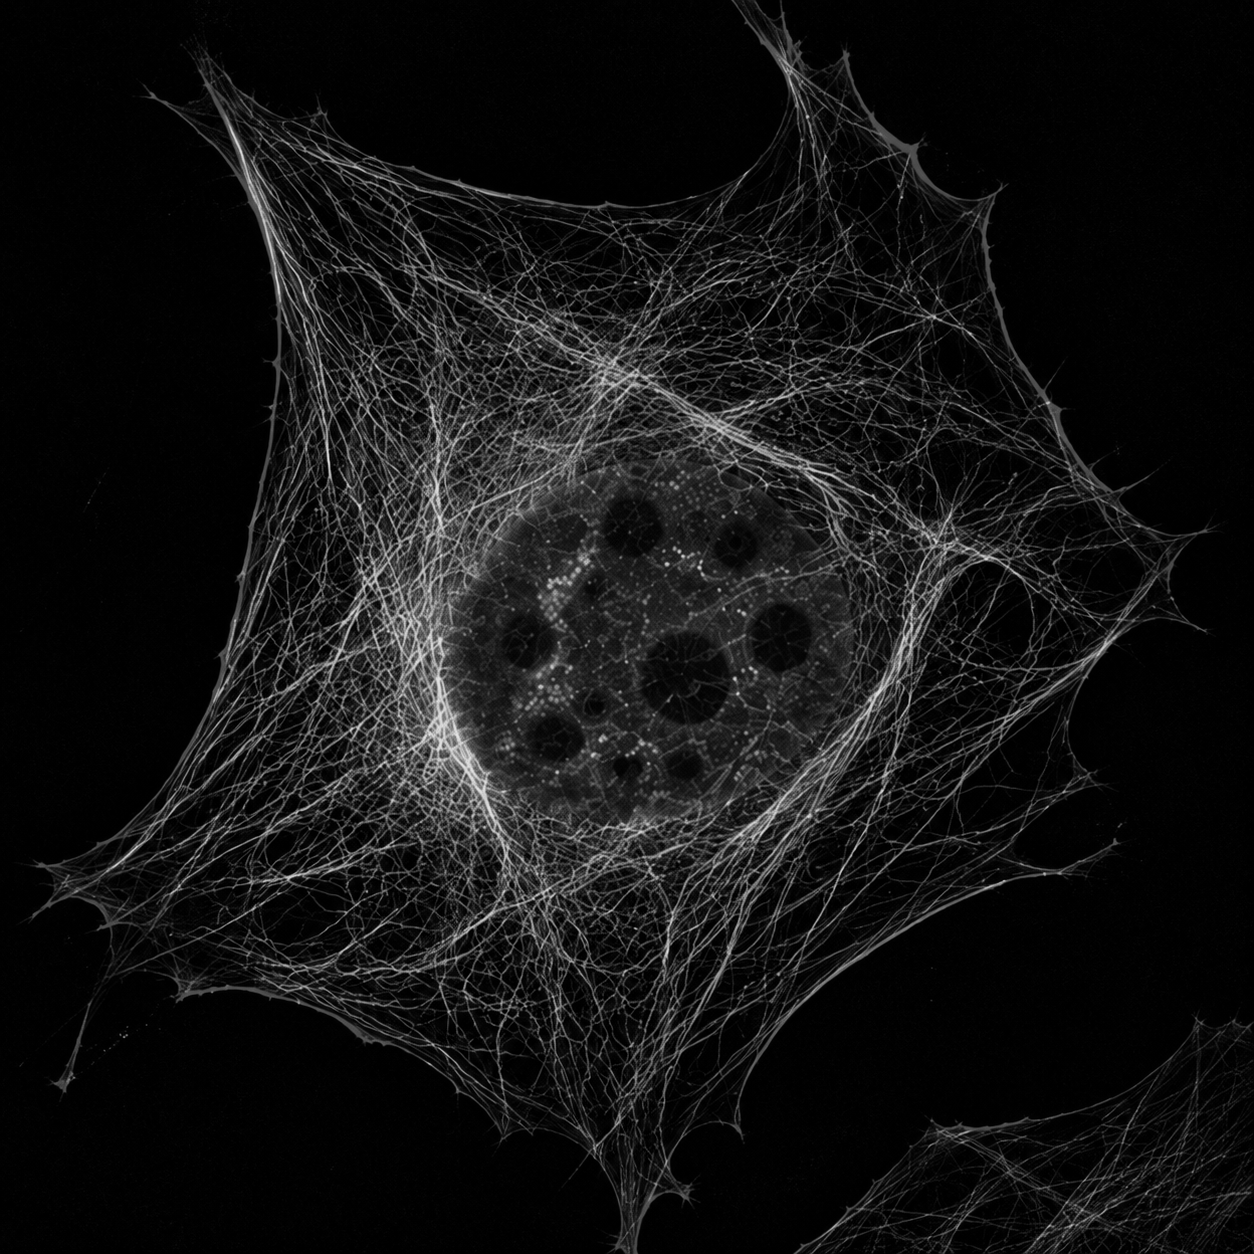

In [14]:

def histogram(im):
    '''Return a histogram as a list,
    where index i holds the number of pixels with value i'''
    mat = im.load()
    width, height = im.size
    hist = [0] * 256    # create a list of 256 zeros

    for x in range(width):
        for y in range(height):
            gray_level = mat[x, y]
            hist[gray_level] += 1

    return hist

histogram_data = histogram(im)
print("Histogram data:", histogram_data)
display(im)

## Code explained - `histogram`

The function returns a list of length 256.

- index `i` stores how many pixels have gray level `i`
- gray levels range from `0` to `255`
- the gray-level value itself is used as a list index

PIL also provides this operation directly through `im.histogram()`.

## 9.1.2 Otsu's Method - Quantities

For every possible threshold `t`, define:

- `back`: number of background pixels with value `<= t`
- `fore`: number of foreground pixels with value `> t`
- `mean_back`: mean value of background pixels
- `mean_fore`: mean value of foreground pixels
- `var_between = back * fore * (mean_back - mean_fore)**2`

Otsu's method chooses the threshold that maximizes `var_between`.

In [ ]:
def otsu_thrd(im):
    '''return the optimal threshold for a 256 gray level image im'''
    width, height = im.size
    hist = histogram(im)
    var_max = 0
    threshold = 0

    for t in range(1, 255):
        back = sum([hist[i] for i in range(t + 1)])
        fore = sum([hist[i] for i in range(t + 1, len(hist))])
        if back == 0 or fore == 0:  # an empty segment
            continue                # move to the next t

        mean_back = sum(hist[i] * i for i in range(t + 1)) / back
        mean_fore = sum(hist[i] * i for i in range(t + 1, len(hist))) / fore

        # Calculate "Between Class Variance"
        var_between = back * fore * (mean_back - mean_fore) ** 2

        # Check if new maximum found
        if var_between > var_max:
            var_max = var_between
            threshold = t

    return threshold

## Code explained - `otsu_thrd`

For every threshold `t` between `1` and `254`, the function:

1. splits the histogram into background and foreground
2. skips empty segments
3. computes the mean gray level in each segment
4. computes the between-class variance
5. stores the best threshold found so far

Thresholds `0` and `255` are skipped because they create zero between-class variance.

In [ ]:
im = Image.open("...")
im = im.convert('L')
otsu_thrd(im)
# Expected for the Figure 9.4 example: 154

## Exercise 2

Find the best threshold by Otsu's method to segment the image in Figure 9.1.

## 9.2 Morphological Operators

Morphological operators change pixels according to the values of nearby pixels.

Key idea: for each pixel, inspect a **neighborhood** around it.

Common neighborhoods:

- 3 by 3 square around a pixel
- larger square
- rectangle
- any symmetric rectangular neighborhood centered at the pixel

## Figure 9.7

<img src="fig9.7.png" width="600">

**Figure 9.7.** A 3 by 3 square neighborhood around the pixel `(x,y)`.

## Figure 9.8

<img src="fig9.8.png" width="600">

**Figure 9.8.** A `(2*kx + 1)` by `(2*ky + 1)` rectangle of pixels centered at `(x, y)`.

## 9.2.1 Erosion and Dilation

For black-white images with white foreground and black background:

- **Erosion** turns a white pixel with at least one black neighbor into black.
- **Dilation** turns a black pixel with at least one white neighbor into white.

For binary images:

- erosion = replace each pixel by the minimum value in its neighborhood
- dilation = replace each pixel by the maximum value in its neighborhood

## Exercise 3

Are erosion and dilation opposite operations?

That is, if we apply one operation and then the other, do we necessarily recover the original image?

## Figure 9.9

<img src="fig9.9.png" width="600">

**Figure 9.9.** (a) Original image. (b) After erosion. (c) After dilation.

## Detour: high-order functions

A high-order function is a function that operates on another function.

Example: `sorted` can receive a function as the `key` parameter.

This is useful for morphological operators because the same neighborhood scan can be reused with different operators:

- `min` for erosion
- `max` for dilation
- `mean` for local means
- `median` for local medians

In [ ]:
sorted([1, -3, 4, 2, -5])

In [ ]:
sorted([1, -3, 4, 2, -5], key=abs)

In [ ]:
sorted(["hi", "hello", "hey"])

In [ ]:
sorted(["hi", "hello", "hey"], key=len)

In [ ]:
def morph_operator(im, op, kx=1, ky=1):
    '''apply operator op on every pixel of im
    with a neighborhood of kx and ky'''
    w, h = im.size
    out_im = im.copy()

    mat = im.load()
    out_mat = out_im.load()

    for x in range(w):
        for y in range(h):
            left = max(0, x - kx)
            up = max(0, y - ky)
            right = min(w - 1, x + kx)
            down = min(h - 1, y + ky)

            xy_neighborhood = im.crop((left, up, right + 1, down + 1))
            xy_neighbors = xy_neighborhood.getdata()
            out_mat[x, y] = op(xy_neighbors)

    return out_im

## Code explained - `morph_operator`

`morph_operator` traverses all pixels and applies a local operator `op`.

For each pixel `(x, y)`:

- compute neighborhood boundaries
- clip the boundaries so they stay inside the image
- crop the neighborhood
- flatten it into a list-like object
- apply `op` to the neighborhood values
- write the result to the output image

In [ ]:
def erosion(im, kx=1, ky=1):
    return morph_operator(im, min, kx, ky)


def dilation(im, kx=1, ky=1):
    return morph_operator(im, max, kx, ky)

## 9.2.1 Opening and Closing

Two common combinations:

- **Opening** = erosion followed by dilation
  - smooths contours
  - breaks thin connections
  - eliminates small islands

- **Closing** = dilation followed by erosion
  - smooths contours
  - merges objects with narrow gaps
  - fills long thin gaps and holes

## Figure 9.10

<img src="fig9.10.png" width="600">

**Figure 9.10.** (a) Original image. (b) Result after the simple edge-detection idea described in the text.

## Figure 9.11

<img src="fig9.11.png" width="600">

**Figure 9.11.** (a) Original image. (b) Eroded image. (c) Edges obtained by subtracting the eroded image from the original image.

## Edge extraction using erosion

Simple idea:

1. Segment the image using Otsu's method.
2. Erode the segmented image.
3. Subtract the eroded image from the segmented image, pixel by pixel.

Pixels removed by erosion become the detected contour.

In [ ]:
def minus(im1, im2):
    '''creates the difference matrix im1-im2 pixel-wise'''
    assert im1.size == im2.size

    w, h = im1.size
    mat1 = im1.load()
    mat2 = im2.load()
    out = im1.copy()
    out_mat = out.load()

    for x in range(w):
        for y in range(h):
            out_mat[x, y] = mat1[x, y] - mat2[x, y]

    return out

In [ ]:
def edges(im):
    t = otsu_thrd(im)
    seg = segment(im, t)
    return minus(seg, erosion(seg))

## Figure 9.12

<img src="fig9.12.png" width="600">

**Figure 9.12.** (a) Original Drosophila Kc167 cell image. (b) Edge extraction using erosion. (c) PIL edge detection.

In [ ]:
im = Image.open("...").convert('L')
edges(im).show()

In [ ]:
from PIL import ImageFilter

pil_edges = im.filter(ImageFilter.FIND_EDGES)
th = otsu_thrd(pil_edges)
seg = segment(pil_edges, th)
seg.show()

## 9.2.2 Noise Reduction (Denoising)

Noise is any deviation from the true pixel value.

For a pixel `(x, y)`:

`M(x, y) = T(x, y) + N(x, y)`

where:

- `T(x, y)` is the true value
- `N(x, y)` is the noise component
- `M(x, y)` is the observed value in the image matrix

## Figure 9.13

<img src="fig9.13.png" width="600">

**Figure 9.13.** (a) Original image. (b) Image after Gaussian noise. (c) Image after balanced salt-and-pepper noise.

## 9.2.2 Noise models

Two common noise models:

**Gaussian noise**

- each pixel is changed by a normally distributed amount
- small deviations are more likely than large deviations

**Salt and pepper noise**

- sparse light and dark disturbances appear in the image
- each pixel may be randomly changed to black or white

## 9.2.2 Local denoising

Local denoising changes each pixel based on its neighborhood.

Two examples:

- **Local medians:** replace each pixel by the median of its neighborhood.
- **Local means:** replace each pixel by the average of its neighborhood.

Local medians are especially effective for salt-and-pepper noise because the median is less sensitive to extreme outliers.

## Figure 9.14

<img src="fig9.14.png" width="600">

**Figure 9.14.** Median vs. mean after a noisy central pixel. The median restores a value close to the original; the mean is more affected by the outlier.

## Figure 9.15

<img src="fig9.15.png" width="600">

**Figure 9.15.** (a) Image with salt-and-pepper noise. (b) After local medians. (c) After local means.

In [ ]:
def mean(lst):
    return round(sum(lst) / len(lst))


def local_means(im, kx=1, ky=1):
    return morph_operator(im, mean, kx, ky)


def median(lst):
    return sorted(lst)[len(lst) // 2]


def local_medians(im, kx=1, ky=1):
    return morph_operator(im, median, kx, ky)

## 9.3 A Biological Application - Cell Quantification

Goal: replace manual cell counting with an image-processing pipeline.

Main tool: **labeling**.

Labeling identifies connected non-black regions in an image. In this context, these regions are interpreted as cells.

## Figure 9.16

<img src="fig9.16.png" width="600">

**Figure 9.16.** (a) A simple black-and-white image. (b) Labeling of connected regions: objects are labeled `1,2,3,4,5`, background is `0`.

## 9.3 Labeling with `scipy`

The `label` function treats:

- non-zero values as features / objects
- zero values as background

It returns:

- a matrix whose connected components have positive integer labels
- the number of detected objects

By default, diagonal touching alone does not connect two pixels.

In [ ]:
from scipy.ndimage.measurements import label

mat = [
    [0, 255, 255, 0, 0, 0],
    [0, 255, 255, 0, 255, 0],
    [0, 0, 255, 0, 0, 0],
    [0, 255, 0, 0, 0, 0],
    [255, 255, 255, 0, 0, 255],
    [0, 255, 0, 255, 0, 255],
]

labeled_array, num_features = label(mat)
print(num_features)
print(labeled_array)

## Figure 9.17

<img src="fig9.17.png" width="600">

**Figure 9.17.** Human colon cancer cells. The task: how many cells are in the image?

In [ ]:
im = Image.open("...")
th = otsu_thrd(im)
print(th)  # example in the chapter: 38

im2 = segment(im, th)

from scipy.ndimage.measurements import label
mat, n = label(im2)
print(n)  # example in the chapter: 367

## 9.3 Cell quantification - limitations

The count may deviate from the true number because:

- segmentation may remove relatively dark cells
- nearby cells may be merged into one connected component
- clusters can be counted as one object

More sophisticated cell quantification methods are beyond the scope of this chapter.

## Reflection

This chapter introduced basic image-processing techniques:

- Digital images are matrices of pixel values.
- Segmentation can be done by thresholding.
- Otsu's method searches for an automatic threshold.
- Erosion and dilation are local morphological operators.
- Edge extraction can be built from segmentation, erosion, and subtraction.
- Local medians and local means can reduce noise.
- Labeling can count connected objects such as cells.

## Figure 9.18

<img src="fig9.18.png" width="600">

**Figure 9.18.** Modular software design illustration.

## Reflection - Modular software design

The code in this chapter demonstrates modular design:

- avoid duplicate code
- define general tools once
- specialize them with different operators

Example hierarchy:

- `morph_operator` is the general local operator
- `erosion`, `dilation`, `local_means`, and `local_medians` are special cases
- `edges` combines segmentation, erosion, and subtraction

## Figure 9.19

<img src="fig9.19.png" width="600">

**Figure 9.19.** Single-particle tracking: frames over time and reconstructed trajectories.

## Reflection - Beyond this chapter

Image processing includes many more tasks, such as tracking objects over time.

Challenges include:

- objects moving quickly between frames
- objects changing orientation or shape
- objects disappearing from the frame
- objects splitting into several objects

Python libraries such as PIL and scipy provide many more image-processing tools.

## Challenge Yourself - Problem 1: Cell quantification

On the website, find the image shown in Figure 9.20.

Task:

Estimate the number of Drosophila Kc167 cells in the image.

You may use Python's labeling and any additional image-processing technique:

- segmentation
- erosion
- dilation
- noise reduction
- combinations of the above

## Figure 9.20

<img src="fig9.20.png" width="600">

**Figure 9.20.** Drosophila Kc167 cells.

## End of Chapter 9

Key computational idea:

Build small reusable functions, then combine them into an image-analysis pipeline.

Typical pipeline for cell counting:

`image -> grayscale -> segmentation -> optional cleanup -> labeling -> count`